# Robust optimisation

> **Uncertainty quantification plugs into every analysis.** A run is deterministic until you add a `uq_config`; with it, the analysis is evaluated over a small Stroud-3 quadrature of the uncertain geometry and returns a distribution (mean, standard deviation). The same pattern works for eigenmode, tuning, wakefield, and optimisation.

**Robust optimisation** puts a `uq_config` inside the optimisation's `eigenmode_config`: every candidate is not just tuned and evaluated, it is evaluated *under uncertainty*, and ranked by a robust objective (mean + k·std) rather than the nominal value. The result is a Pareto front of designs that stay good across the tolerance band, not just at the nominal point.

Kept tiny (a couple of candidates, one generation) so it runs in a few minutes — each candidate is a full UQ sweep.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt

from cavsim2d import Cavities, EllipticalCavity
from cavsim2d.utils.style import apply_style

apply_style()

## 1. The search space and the uncertainty

Sweep the ellipse semi-axes `A, B`; tune `Req` to 1300 MHz for every candidate; minimise the peak-field ratios **under a 2% spread** on `A, B` (the `uq_config` nested in the eigenmode config).

In [2]:
cavs = Cavities(os.path.join(tempfile.mkdtemp(), 'robust_opt'))
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]
cavs.add_cavity([EllipticalCavity(1, midcell, midcell, midcell, beampipe='none')], ['TESLA'])

config = {
    'initial_points': 2, 'no_of_generation': 1,
    'method': {'LHS': {'seed': 5}},
    'bounds': {'A': [40, 46], 'B': [40, 46]},
    'objectives': [['min', 'monopole:Epk/Eacc []'],
                   ['min', 'monopole:Bpk/Eacc [mT/MV/m]']],
    'tune_config': {
        'freqs': 1300.0, 'cell_type': {'mid-cell': 'Req'}, 'processes': 1,
        'eigenmode_config': {
            'n_cells': 1, 'processes': 1, 'boundary_conditions': 'mm',
            'uq_config': {
                'variables': ['A', 'B'],
                'objectives': ['monopole:Epk/Eacc []', 'monopole:Bpk/Eacc [mT/MV/m]'],
                'method': ['stroud3'], 'delta': [0.02, 0.02], 'processes': 1,
                'cell_type': 'mid-cell', 'cell_complexity': 'simplecell',
            },
        },
    },
    'mutation_factor': 2, 'crossover_factor': 2, 'elites_for_crossover': 2,
    'chaos_factor': 2, 'weights': [1, 1],
}

## 2. Run it

In [3]:
cavs.run_optimisation(config)
opt = cavs.optimisation
print(f'evaluated candidates: {len(opt.history)}')

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [01:46<00:00, 106.31s/it]

evaluated candidates: 2


## 3. Robust objective columns

For each objective the history now carries the **mean** `E[...]`, the **standard deviation** `std[...]`, and the **robust value** `E[...] + 6·std[...]` that the candidates are ranked by — so a design with a slightly worse nominal but a much tighter spread can win.

In [4]:
cols = [c for c in opt.history.columns
        if c.startswith(('E[', 'std['))]
opt.history[cols].round(4)

,E[monopole:Epk/Eacc []],std[monopole:Epk/Eacc []],E[monopole:Epk/Eacc []] + 6*std[monopole:Epk/Eacc []],E[monopole:Bpk/Eacc [mT/MV/m]],std[monopole:Bpk/Eacc [mT/MV/m]],E[monopole:Bpk/Eacc [mT/MV/m]] + 6*std[monopole:Bpk/Eacc [mT/MV/m]]
0,2.031,0.0164,2.1294,4.1584,0.0005,4.1615
1,2.031,0.0164,2.1294,4.1584,0.0005,4.1615


## 4. The Pareto front (robust objectives)

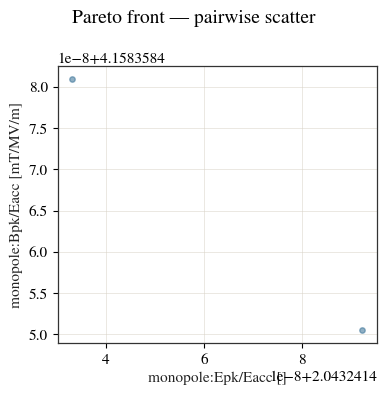

In [5]:
opt.plot_pareto(kind='scatter', normalise=False)
plt.show()

See also: [eigenmode UQ](eigenmode_uq.ipynb) and [robust tuning](robust_tuning.ipynb).